In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import ast


In [3]:
# Uploading processed SafeDial and LMSYS datasets
lmsys_proc = pd.read_csv('../data/processed/lmsys_processed.csv') 
safedial_proc = pd.read_csv('../data/processed/safedial_processed.csv')


In [4]:
# Candidates for multi-turn benign conversations from LMSYS to enrich SafeDial dataset
# Very large pool of data to work with (200,000+ conversations)

len(lmsys_proc)

215901

In [ ]:
# Taking a look at conversation with redacted name
# Verifying that name replacement code worked!

# Looking at short convo for convenience 
ind = lmsys_proc[(lmsys_proc['redacted'] == True) & (lmsys_proc['conv_length'] < 100)].sample().index[0]
# Print convo before and after redaction replacement
print(lmsys_proc[lmsys_proc['redacted'] == True].loc[ind]['conversation'])
print('\n', lmsys_proc[lmsys_proc['redacted'] == True].loc[ind]['conversation_enriched'])

[{'content': 'hello', 'role': 'user'}
 {'content': 'Hello! My name is NAME_1.', 'role': 'assistant'}
 {'content': 'hello', 'role': 'user'}
 {'content': 'Hi there! How can I help you?', 'role': 'assistant'}]

 [{'role': 'user', 'content': 'hello'}, {'role': 'assistant', 'content': 'Hello! My name is Cynara.'}, {'role': 'user', 'content': 'hello'}, {'role': 'assistant', 'content': 'Hi there! How can I help you?'}]


LMSYS (benign):
count    2.159010e+05
mean     3.841914e+03
std      2.790984e+04
min      8.000000e+00
25%      1.319000e+03
50%      2.623000e+03
75%      4.539000e+03
max      6.663975e+06
Name: conv_length, dtype: float64

SafeDial (harmful):
count     2037.000000
mean     17940.497791
std       8678.502732
min        955.000000
25%      11075.000000
50%      17175.000000
75%      24378.000000
max      45810.000000
Name: conv_length, dtype: float64


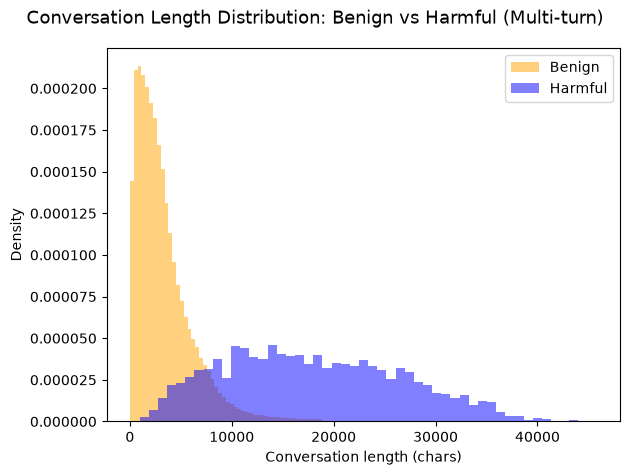

X-axis capped at: 18,861 chars (99th percentile of benign)
Benign outliers excluded from plot: 2159


In [18]:
# Comparing length distributions between the two datasets

print("LMSYS (benign):")
print(lmsys_proc['conv_length'].describe())
print("\nSafeDial (harmful):")
print(safedial_proc['conv_length'].describe())

# Removing outliers above 99th percentile to avoid skew
xlim = np.percentile(lmsys_proc['conv_length'], 99)
lmsys_for_viz = lmsys_proc[lmsys_proc['conv_length'] < xlim]

plt.hist(lmsys_for_viz['conv_length'], bins=50, alpha=0.5, label='Benign', color='orange', density=True)
plt.hist(safedial_proc['conv_length'], bins=50, alpha=0.5, label='Harmful', color='blue', density=True)
plt.xlabel('Conversation length (chars)')
plt.ylabel('Density')
plt.legend()

plt.suptitle('Conversation Length Distribution: Benign vs Harmful (Multi-turn)', fontsize=13)
plt.tight_layout()
plt.show()

print(f"X-axis capped at: {xlim:,.0f} chars (99th percentile of benign)")
print(f"Benign outliers excluded from plot: {(lmsys_proc['conv_length'] > xlim).sum()}")

LMSYS (benign):
count    215901.000000
mean          3.842192
std           3.504774
min           2.000000
25%           2.000000
50%           3.000000
75%           4.000000
max         172.000000
Name: turn, dtype: float64

SafeDial (harmful):
count    2037.000000
mean        4.923417
std         0.479467
min         3.000000
25%         5.000000
50%         5.000000
75%         5.000000
max         9.000000
Name: turn, dtype: float64


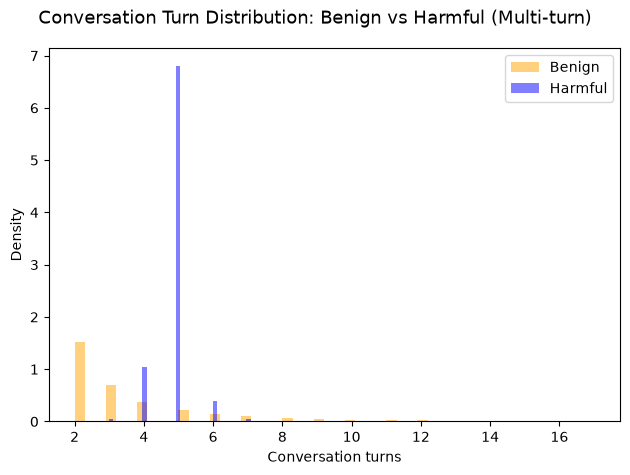

In [19]:
# Comparing turn distributions

print("LMSYS (benign):")
print(lmsys_proc['turn'].describe())
print("\nSafeDial (harmful):")
print(safedial_proc['turn'].describe())

# Removing outliers above 99th percentile to avoid skew
xlim = np.percentile(lmsys_proc['turn'], 99)
lmsys_for_viz = lmsys_proc[lmsys_proc['turn'] < xlim]

plt.hist(lmsys_for_viz['turn'], bins=50, alpha=0.5, label='Benign', color='orange', density=True)
plt.hist(safedial_proc['turn'], bins=50, alpha=0.5, label='Harmful', color='blue', density=True)
plt.xlabel('Conversation turns')
plt.ylabel('Density')
plt.legend()

plt.suptitle('Conversation Turn Distribution: Benign vs Harmful (Multi-turn)', fontsize=13)
plt.tight_layout()
plt.show()

In [20]:
# Will stratify sample of LMSYS to match the distribution of conversation lengths in SafeDial
# Exploring the data available in LMSYS

# Use SafeDials's range as the reference
xlim = safedial_proc['conv_length'].max()

# Check what % of benign falls within harmful's range
benign_in_range = (lmsys_proc['conv_length'] <= xlim).mean()
print(f"% of benign data within harmful length range: {benign_in_range:.1%}")

# Summarize the mismatch
print("\nBenign median:", lmsys_proc['conv_length'].median())
print("Harmful median:", safedial_proc['conv_length'].median())

% of benign data within harmful length range: 99.9%

Benign median: 2623.0
Harmful median: 17175.0


In [25]:
# Define bins based on harmful's distribution
n_bins = 20
_, bin_edges = np.histogram(safedial_proc['conv_length'], bins=n_bins)

# Expand left edge slightly to include minimum value
bin_edges[0] = bin_edges[0] - 0.001

harmful_binned = pd.cut(safedial_proc['conv_length'], bins=bin_edges)
harmful_bin_counts = harmful_binned.value_counts().sort_index()

benign_binned = pd.cut(lmsys_proc['conv_length'], bins=bin_edges)
benign_bin_counts = benign_binned.value_counts().sort_index()

comparison = pd.DataFrame({
    'harmful_needed': harmful_bin_counts,
    'benign_available': benign_bin_counts
}).fillna(0).astype(int)

comparison['sufficient'] = comparison['benign_available'] >= comparison['harmful_needed']
comparison['shortfall'] = (comparison['harmful_needed'] - comparison['benign_available']).clip(lower=0)

print(comparison)
print(f"\nBins with insufficient benign data: {(~comparison['sufficient']).sum()}/{n_bins}")
print(f"Total harmful: {harmful_bin_counts.sum()} (should be {len(safedial_proc)})")

                     harmful_needed  benign_available  sufficient  shortfall
conv_length                                                                 
(954.999, 3197.75]               34             90551        True          0
(3197.75, 5440.5]                92             48304        True          0
(5440.5, 7683.25]               138             21647        True          0
(7683.25, 9926.0]               143              9059        True          0
(9926.0, 12168.75]              205              3318        True          0
(12168.75, 14411.5]             183              1639        True          0
(14411.5, 16654.25]             187              1006        True          0
(16654.25, 18897.0]             168               713        True          0
(18897.0, 21139.75]             154               480        True          0
(21139.75, 23382.5]             161               351        True          0
(23382.5, 25625.25]             142               247        True          0

In [ ]:
# Building exploratory benign sample, stratified by conversation length

SEED = 1234

samples = []
for interval, row in comparison.iterrows():
    n_needed = row['harmful_needed']
    bin_data = lmsys_proc[
        (lmsys_proc['conv_length'] > interval.left) &
        (lmsys_proc['conv_length'] <= interval.right)
    ]
    samples.append(bin_data.sample(n_needed, random_state=SEED))

benign_length_matched = pd.concat(samples)

print(f"Matched benign size: {len(benign_length_matched)}")
print(f"Harmful size: {len(safedial_proc)}")
print(f"\nBenign median: {benign_length_matched['conv_length'].median():,.0f}")
print(f"Harmful median: {safedial_proc['conv_length'].median():,.0f}")

Matched benign size: 2037
Harmful size: 2037

Benign median: 17,186
Harmful median: 17,175


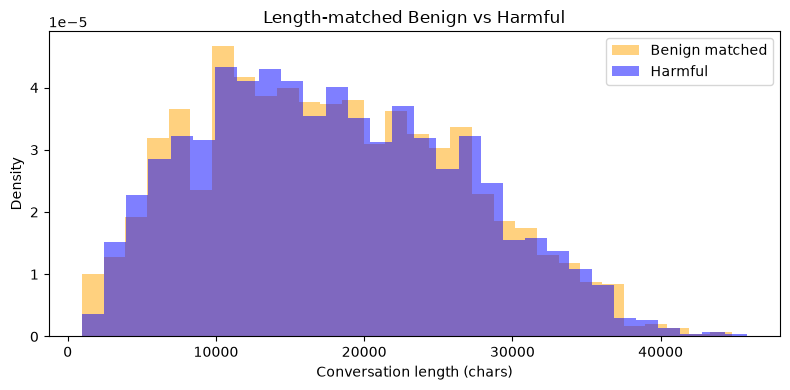

In [27]:
# Updated distribution after matching

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(benign_length_matched['conv_length'], bins=30, alpha=0.5, label='Benign matched', color='orange', density=True)
ax.hist(safedial_proc['conv_length'], bins=30, alpha=0.5, label='Harmful', color='blue', density=True)
ax.set_xlabel('Conversation length (chars)')
ax.set_ylabel('Density')
ax.set_title('Length-matched Benign vs Harmful')
ax.legend()
plt.tight_layout()
plt.show()

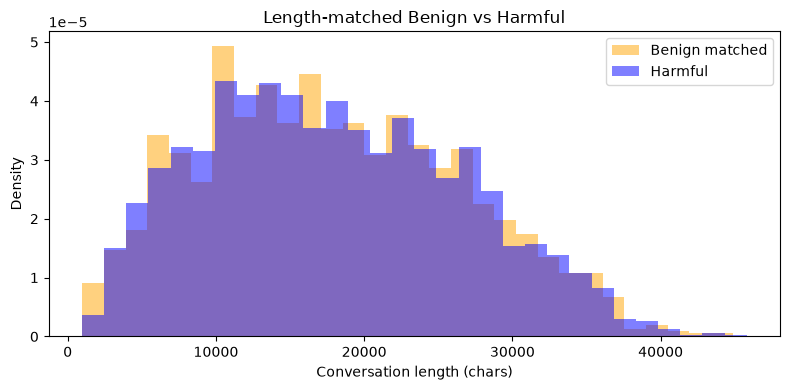

In [28]:
# Comparing this to the final dataset generated by build_multiturn_data.py for sanity check 
# Should look identical since that file uses exactly the same method as this notebook

merged = pd.read_csv('../data/processed/safedial_enriched_with_benign.csv')
benign = merged[merged['harm'] == False].copy()
harmful = merged[merged['harm'] == True].copy()

def conversation_length_from_json(conversation_str):
    """Parse JSON string back to list then measure content length"""
    try:
        conversation = json.loads(conversation_str)
        return sum(
            len(msg.get('content', ''))
            for msg in conversation
            if isinstance(msg.get('content'), str)
        )
    except:
        return len(conversation_str)  # fallback

benign['conv_length'] = benign['conversation'].apply(conversation_length_from_json)
harmful['conv_length'] = harmful['conversation'].apply(conversation_length_from_json)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(benign['conv_length'], bins=30, alpha=0.5, label='Benign matched', color='orange', density=True)
ax.hist(harmful['conv_length'], bins=30, alpha=0.5, label='Harmful', color='blue', density=True)
ax.set_xlabel('Conversation length (chars)')
ax.set_ylabel('Density')
ax.set_title('Length-matched Benign vs Harmful')
ax.legend()
plt.tight_layout()
plt.show()

In [47]:
# Checking out other characteristics shared by the two datasets

print('Model Distributions (%)')
print('-----------------------')
print('\nBenign:')
print('\n', round((100*benign_length_matched['model'].value_counts() / len(benign_length_matched)),2))
print('\nHarmful:')
print('\n', round((100*safedial_proc['model_type'].value_counts() / len(benign_length_matched)),2), '\n')

print('Turn Distributions (%)')
print('-----------------------')
print('\nBenign:')
print('\n', round((100*benign_length_matched['turn'].value_counts() / len(benign_length_matched)),2))
print('\nHarmful:')
print('\n', round((100*safedial_proc['turn'].value_counts() / len(benign_length_matched)),2))

Model Distributions (%)
-----------------------

Benign:

 model
vicuna-13b                 60.78
claude-1                    8.54
koala-13b                   6.63
gpt-4                       4.71
alpaca-13b                  2.11
oasst-pythia-12b            1.62
chatglm-6b                  1.57
vicuna-7b                   1.52
claude-instant-1            1.37
vicuna-33b                  1.28
llama-2-13b-chat            1.18
wizardlm-13b                1.13
RWKV-4-Raven-14B            1.08
fastchat-t5-3b              0.93
mpt-30b-chat                0.88
llama-13b                   0.79
dolly-v2-12b                0.74
guanaco-33b                 0.64
mpt-7b-chat                 0.59
stablelm-tuned-alpha-7b     0.59
gpt-3.5-turbo               0.44
palm-2                      0.34
llama-2-7b-chat             0.20
gpt4all-13b-snoozy          0.20
claude-2                    0.15
Name: count, dtype: float64

Harmful:

 model_type
ChatGPT    100.0
Name: count, dtype: float64 

Turn Distrib

In [48]:
# Characteristics only in the benign dataset

print('Redacted (%)')
print('------------')
print('\nBenign:')
print('\n', round((100*benign_length_matched['redacted'].value_counts() / len(benign_length_matched)),2))

Redacted (%)
------------

Benign:

 redacted
True     72.61
False    27.39
Name: count, dtype: float64


In [50]:
# Characteristics only in the harmful dataset

print('Redacted (%)')
print('------------')
print('\nHarmful:')
print('\n', round((100*safedial_proc['method'].value_counts() / len(safedial_proc)),2))

print('Scene (%)')
print('------------')
print('\nHarmful:')
print('\n', round((100*safedial_proc['scene'].value_counts() / len(safedial_proc)),2))

Redacted (%)
------------

Harmful:

 method
Reference Attack    25.77
Scence Construct    25.33
Purpose Reverse     19.98
Role Play            9.62
Probing Question     7.61
Topic Change         6.33
Fallacy Attack       5.35
Name: count, dtype: float64
Scene (%)
------------

Harmful:

 scene
Law and Morality                        24.30
Privacy and Security                    12.67
Social Affairs                          11.19
Employment                               8.59
Daily Life                               8.10
Education                                4.86
Interpeonal Relationships                4.32
Healthcare                               3.93
Race and Religion                        3.78
Child Protection and Development         2.50
Marriage and Affection                   2.50
Animal Protection                        2.41
Campus Affairs                           2.06
Business Management                      2.01
Internet Information                     1.52
Financial Tech